In [ ]:
#  STEP 1 — Import Required Libraries

# Install visualization library (run only once)
%pip install -q seaborn

# Data Handling Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages (for clean output)
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, classification_report

# File Handling Libraries
import glob
import os

print(" Step 1 Completed — All Required Libraries Imported Successfully!")

Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully!


In [34]:
import os
import pandas as pd

print("=" * 70)
print("Loading Production Line Data")
print("=" * 70)

data_dir = r"D:\Production Line Bottleneck\data"
dataset_path = os.path.join(data_dir, "dataset.csv")

train_data = pd.DataFrame()
test_data = pd.DataFrame()

if not os.path.exists(dataset_path):
    print(f"Dataset not found: {dataset_path}")
    print(f"Current working directory: {os.getcwd()}")
    print("Please ensure dataset.csv exists at the correct location.")
else:
    print(f"Dataset found: {dataset_path}")
    try:
        train_data = pd.read_csv(dataset_path)
        print("\nDataset loaded successfully")

        print(f"Shape: {train_data.shape}")
        print(f"Columns: {list(train_data.columns)}")

        print("\nFirst few rows:")
        print(train_data.head())

        print("\nData types:")
        print(train_data.dtypes)

        train_data["Production_Issue"] = (
            (train_data["Defect_Rate"].astype(float) > 0.06)
            | (train_data["Downtime"].astype(float) > 12)
        ).astype(int)

        print("\nProduction issue label created")
        print("Production issue distribution:")
        print(train_data["Production_Issue"].value_counts())

        test_data = train_data.copy()

    except Exception as e:
        print(f"Error loading dataset: {str(e)}")
        train_data = pd.DataFrame()
        test_data = pd.DataFrame()

Loading Production Line Data
Dataset found: D:\Production Line Bottleneck\data\dataset.csv

Dataset loaded successfully
Shape: (20, 6)
Columns: ['Stage', 'Cycle_Time', 'Waiting_Time', 'Downtime', 'Defect_Rate', 'Units_Produced']

First few rows:
      Stage  Cycle_Time  Waiting_Time  Downtime  Defect_Rate  Units_Produced
0  Assembly        45.2          15.3       8.5         0.05             280
1  Assembly        52.1          18.2      12.1         0.07             245
2   Welding        65.3          22.1      15.2         0.08             200
3   Welding        58.7          20.1      10.5         0.06             220
4  Painting        48.2          12.1       5.2         0.03             350

Data types:
Stage              object
Cycle_Time        float64
Waiting_Time      float64
Downtime          float64
Defect_Rate       float64
Units_Produced      int64
dtype: object

Production issue label created
Production issue distribution:
Production_Issue
0    15
1     5
Name: count, 

In [35]:
print("\nFiles in current directory:")
print(os.listdir(os.getcwd()))

print("\nSearching for CSV files in common locations...")
search_paths = [
    os.getcwd(),
    os.path.expanduser("~/Downloads"),
    r"D:\Production Line Bottleneck\data",
    os.path.join(os.getcwd(), "data"),
]

for path in search_paths:
    if os.path.exists(path):
        csv_files_found = glob.glob(os.path.join(path, "*.csv"))
        if csv_files_found:
            print(f"\nFound {len(csv_files_found)} CSV files in: {path}")
            for f in csv_files_found:
                print(f" - {os.path.basename(f)}")

print("\nIf your data is in a different location:")
print("1. Edit the 'data_dir' variable in Step 2 to point to your data folder")
print("2. Run Step 2 again")
print("Example: data_dir = r'C:\\path\\to\\your\\data'")


Files in current directory:
['bottleneck.ipynb']

Searching for CSV files in common locations...

Found 1 CSV files in: C:\Users\smidh/Downloads
 - Healthcare Data Analysis for Patient Outcomes.csv

Found 8 CSV files in: D:\Production Line Bottleneck\data
 - dataset.csv
 - sample_submission.csv
 - test_categorical.csv
 - test_date.csv
 - test_numeric.csv
 - train_categorical.csv
 - train_date.csv
 - train_numeric.csv

If your data is in a different location:
1. Edit the 'data_dir' variable in Step 2 to point to your data folder
2. Run Step 2 again
Example: data_dir = r'C:\path\to\your\data'


In [36]:
try:
    if train_data is None or train_data.empty:
        raise ValueError("train_data is empty")

    print("=" * 70)
    print("Data Cleaning and Preprocessing")
    print("=" * 70)

    df = train_data.copy()

    print("\nDataset Overview:")
    print(f"Shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

    print("\nMissing Values (Top 10):")
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    print(missing_pct[missing_pct > 0].head(10))

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    date_cols = []

    numeric_cols = [col for col in numeric_cols if col.lower() not in ['id', 'production_issue']]

    print("\nColumn Types:")
    print(f"Numeric columns: {len(numeric_cols)}")
    print(f"Categorical columns: {len(categorical_cols)}")

    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    for col in categorical_cols:
        if col != 'Production_Issue':
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

    print("\nMissing values handled")
    print("\nBasic Statistics (Numeric):")
    print(df[numeric_cols[:5]].describe().round(2))

except NameError:
    print("Error: Data not loaded yet")
    print("Please run Step 1 and Step 2 to load the dataset")

except ValueError:
    print("Error: train_data is empty")
    print("Step 2 did not load any data. Please check the dataset path")

Data Cleaning and Preprocessing

Dataset Overview:
Shape: (20, 7)
Memory usage: 0.00 MB

Missing Values (Top 10):
Series([], dtype: float64)

Column Types:
Numeric columns: 5
Categorical columns: 1

Missing values handled

Basic Statistics (Numeric):
       Cycle_Time  Waiting_Time  Downtime  Defect_Rate  Units_Produced
count       20.00         20.00     20.00        20.00           20.00
mean        48.10         13.71      7.78         0.04          320.00
std         10.40          5.81      4.40         0.02           85.73
min         32.10          5.20      2.10         0.01          190.00
25%         39.78          8.88      3.88         0.02          242.50
50%         48.15         13.70      7.15         0.04          325.00
75%         54.40         18.42     10.90         0.06          392.50
max         68.10         24.20     16.10         0.09          450.00


In [37]:
print("=" * 70)
print("Feature Engineering - Bottleneck Score")
print("=" * 70)

df_numeric = df[numeric_cols].copy()
df_numeric_normalized = (df_numeric - df_numeric.mean()) / (df_numeric.std() + 1e-8)

df["Bottleneck_Score"] = df_numeric_normalized.abs().mean(axis=1)

df["Missing_Features_Ratio"] = df.isnull().sum(axis=1) / df.shape[1]

df["Efficiency_Score"] = (
    df["Bottleneck_Score"] * 0.6 +
    df["Missing_Features_Ratio"] * 0.4
)

print("\nFeature engineering completed")

print("\nBottleneck Score Statistics:")
print(df["Bottleneck_Score"].describe().round(4))

print("\nEfficiency Score Statistics:")
print(df["Efficiency_Score"].describe().round(4))

if 'Production_Issue' in df.columns:
    print("\nCorrelation with Production Issues:")
    print(f"Bottleneck Score: {df['Bottleneck_Score'].corr(df['Production_Issue']):.4f}")
    print(f"Efficiency Score: {df['Efficiency_Score'].corr(df['Production_Issue']):.4f}")

Feature Engineering - Bottleneck Score

Feature engineering completed

Bottleneck Score Statistics:
count    20.0000
mean      0.8407
std       0.4823
min       0.1443
25%       0.3817
50%       0.8722
75%       1.1540
max       1.7937
Name: Bottleneck_Score, dtype: float64

Efficiency Score Statistics:
count    20.0000
mean      0.5044
std       0.2894
min       0.0866
25%       0.2290
50%       0.5233
75%       0.6924
max       1.0762
Name: Efficiency_Score, dtype: float64

Correlation with Production Issues:
Bottleneck Score: 0.5267
Efficiency Score: 0.5267


In [38]:
print("=" * 70)
print("Production Line Analysis")
print("=" * 70)

df["Severity"] = pd.cut(
    df["Efficiency_Score"],
    bins=4,
    labels=["Excellent", "Good", "Poor", "Critical"]
)

print("\nProduction Status Distribution:")
print(df["Severity"].value_counts().sort_index())

if 'Production_Issue' in df.columns:
    issue_records = df[df['Production_Issue'] == 1]
    print(f"\nRecords with Production Issues: {len(issue_records)} ({len(issue_records)/len(df)*100:.1f}%)")
    print("\nAverage Efficiency Score by Status:")
    print(df.groupby('Production_Issue')['Efficiency_Score'].describe().round(4))

print("\nTop 10 Most Critical Records:")
top_issues = df.nlargest(10, "Efficiency_Score")[
    ["Efficiency_Score", "Bottleneck_Score", "Missing_Features_Ratio", "Severity"]
]
print(top_issues.round(4))

print("\nFeatures with Highest Variance:")
feature_variance = df[numeric_cols].var().sort_values(ascending=False).head(10)
print(feature_variance.round(4))

Production Line Analysis

Production Status Distribution:
Severity
Excellent    7
Good         4
Poor         6
Critical     3
Name: count, dtype: int64

Records with Production Issues: 5 (25.0%)

Average Efficiency Score by Status:
                  count    mean     std     min     25%     50%     75%  \
Production_Issue                                                          
0                  15.0  0.4186  0.2578  0.0866  0.2040  0.3685  0.6088   
1                   5.0  0.7617  0.2340  0.4849  0.6328  0.7008  0.9137   

                     max  
Production_Issue          
0                 0.8643  
1                 1.0762  

Top 10 Most Critical Records:
    Efficiency_Score  Bottleneck_Score  Missing_Features_Ratio  Severity
12            1.0762            1.7937                     0.0  Critical
2             0.9137            1.5228                     0.0  Critical
8             0.8643            1.4406                     0.0  Critical
18            0.8039            1.3

Visualization - Bottleneck Analysis


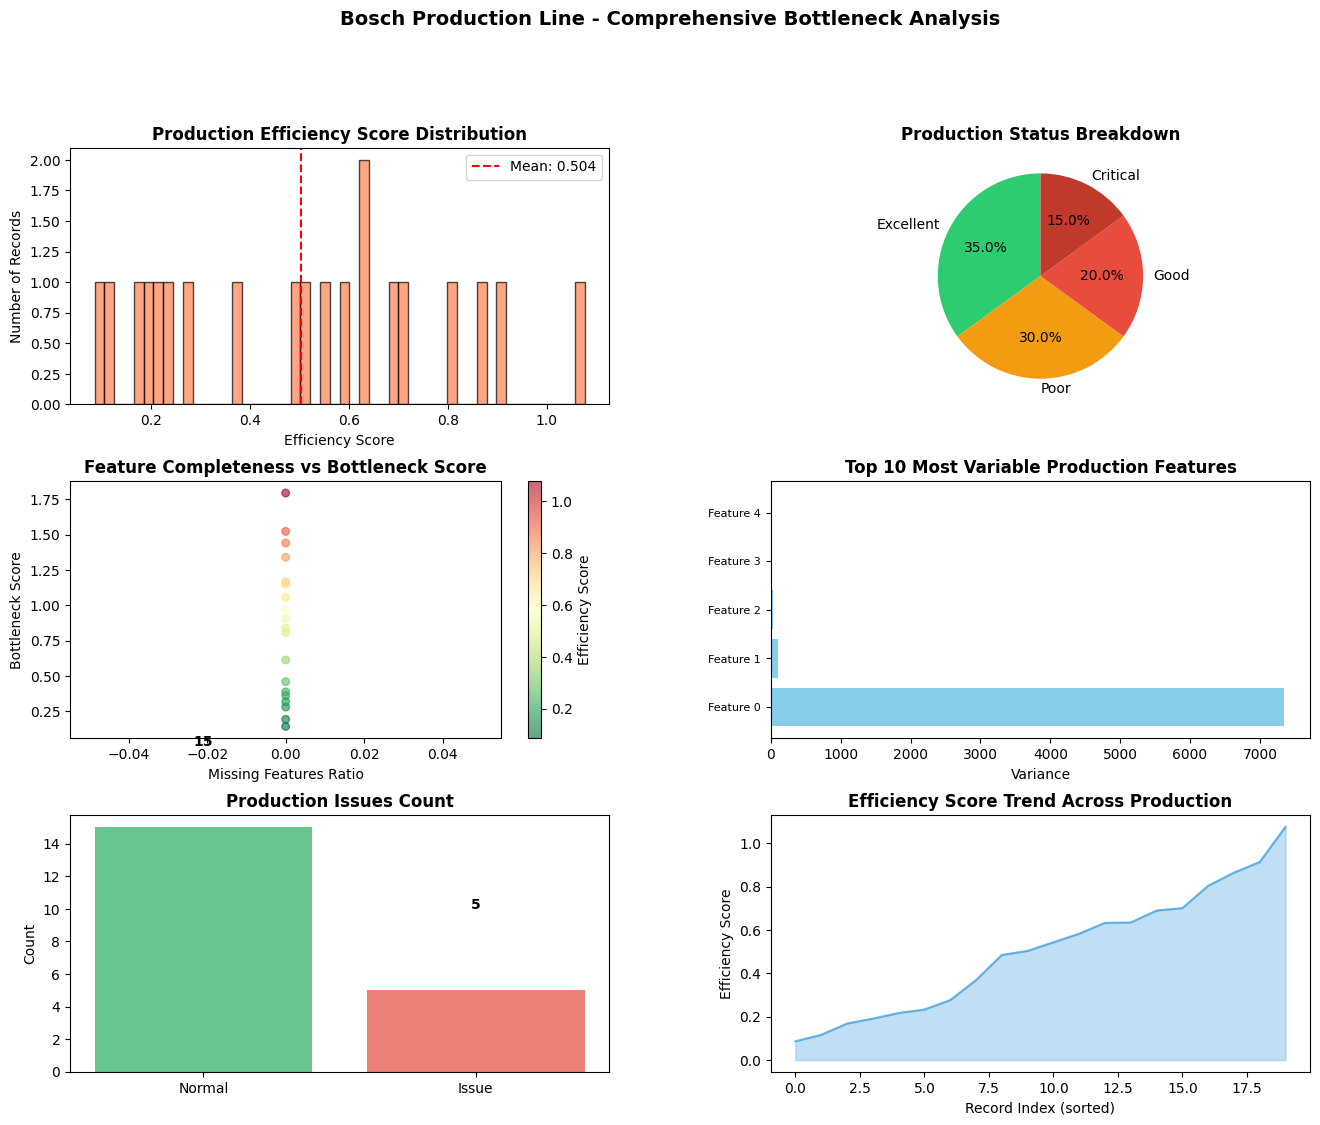


Visualizations complete


In [39]:
print("=" * 70)
print("Visualization - Bottleneck Analysis")
print("=" * 70)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["Efficiency_Score"], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax1.axvline(df["Efficiency_Score"].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Efficiency_Score"].mean():.3f}')
ax1.set_title("Production Efficiency Score Distribution", fontweight='bold', fontsize=12)
ax1.set_xlabel("Efficiency Score")
ax1.set_ylabel("Number of Records")
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
severity_counts = df["Severity"].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
ax2.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
        colors=colors[:len(severity_counts)], startangle=90)
ax2.set_title("Production Status Breakdown", fontweight='bold', fontsize=12)

ax3 = fig.add_subplot(gs[1, 0])
scatter = ax3.scatter(df["Missing_Features_Ratio"], df["Bottleneck_Score"],
                      c=df["Efficiency_Score"], cmap='RdYlGn_r', alpha=0.6, s=30)
ax3.set_xlabel("Missing Features Ratio")
ax3.set_ylabel("Bottleneck Score")
ax3.set_title("Feature Completeness vs Bottleneck Score", fontweight='bold', fontsize=12)
plt.colorbar(scatter, ax=ax3, label="Efficiency Score")

ax4 = fig.add_subplot(gs[1, 1])
feature_stats = pd.DataFrame({
    'Variance': df[numeric_cols].var(),
    'Mean': df[numeric_cols].mean()
}).sort_values('Variance', ascending=False).head(10)
ax4.barh(range(len(feature_stats)), feature_stats['Variance'], color='skyblue')
ax4.set_yticks(range(len(feature_stats)))
ax4.set_yticklabels([f"Feature {i}" for i in range(len(feature_stats))], fontsize=8)
ax4.set_xlabel("Variance")
ax4.set_title("Top 10 Most Variable Production Features", fontweight='bold', fontsize=12)

ax5 = fig.add_subplot(gs[2, 0])
if 'Production_Issue' in df.columns:
    issue_counts = df['Production_Issue'].value_counts()
    ax5.bar(['Normal', 'Issue'], issue_counts.values,
            color=['#27ae60', '#e74c3c'], alpha=0.7)
    ax5.set_ylabel("Count")
    ax5.set_title("Production Issues Count", fontweight='bold', fontsize=12)
    for i, v in enumerate(issue_counts.values):
        ax5.text(i, v + 5, str(v), ha='center', fontweight='bold')

ax6 = fig.add_subplot(gs[2, 1])
sorted_efficiency = df["Efficiency_Score"].sort_values().reset_index(drop=True)
ax6.plot(sorted_efficiency.values, color='#3498db', linewidth=1.5, alpha=0.7)
ax6.fill_between(range(len(sorted_efficiency)), sorted_efficiency.values,
                 alpha=0.3, color='#3498db')
ax6.set_xlabel("Record Index (sorted)")
ax6.set_ylabel("Efficiency Score")
ax6.set_title("Efficiency Score Trend Across Production", fontweight='bold', fontsize=12)

plt.suptitle("Bosch Production Line - Comprehensive Bottleneck Analysis",
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\nVisualizations complete")

Machine Learning - Production Pattern Clustering

Production Line Cluster Distribution:
Cluster 0:    2 records ( 10.0%)
Cluster 1:    7 records ( 35.0%)
Cluster 2:    6 records ( 30.0%)
Cluster 3:    5 records ( 25.0%)

Average Efficiency Score by Cluster:
                    Efficiency_Score  Bottleneck_Score
Production_Cluster                                    
0                             0.9950            1.6583
1                             0.6353            1.0589
2                             0.1688            0.2813
3                             0.5276            0.8793

Production Issues by Cluster:
Production_Issue    0  1
Production_Cluster      
0                   0  2
1                   7  0
2                   6  0
3                   2  3


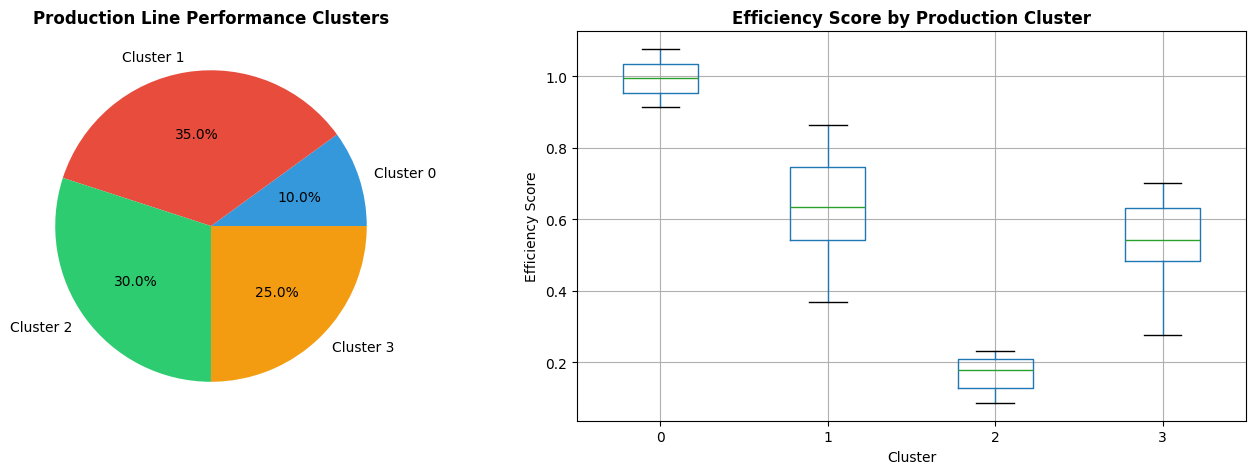


Clustering analysis complete


In [40]:
print("=" * 70)
print("Machine Learning - Production Pattern Clustering")
print("=" * 70)

top_features_idx = df[numeric_cols].var().argsort()[-20:][::-1]
features_for_clustering = [numeric_cols[i] for i in top_features_idx]

features = df[features_for_clustering].copy()
features.fillna(features.mean(), inplace=True)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Production_Cluster"] = kmeans.fit_predict(features_scaled)

print("\nProduction Line Cluster Distribution:")
cluster_dist = df["Production_Cluster"].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    pct = count / len(df) * 100
    print(f"Cluster {cluster}: {count:4d} records ({pct:5.1f}%)")

print("\nAverage Efficiency Score by Cluster:")
print(df.groupby("Production_Cluster")[["Efficiency_Score", "Bottleneck_Score"]].mean().round(4))

if 'Production_Issue' in df.columns:
    print("\nProduction Issues by Cluster:")
    print(df.groupby("Production_Cluster")["Production_Issue"].value_counts().unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(cluster_dist,
            labels=[f"Cluster {i}" for i in cluster_dist.index],
            autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_title("Production Line Performance Clusters", fontweight='bold', fontsize=12)

df.boxplot(column='Efficiency_Score', by='Production_Cluster', ax=axes[1])
axes[1].set_title("Efficiency Score by Production Cluster", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Efficiency Score")
plt.suptitle("")

plt.tight_layout()
plt.show()

print("\nClustering analysis complete")

Machine Learning - Production Bottleneck Prediction

Data Split:
Training set size: 16
Testing set size: 4
Issue distribution in train: {0: 12, 1: 4}

Model training complete
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         3
       Issue       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Top Features for Issue Detection:
          Feature  Importance
3     Defect_Rate    0.295925
2        Downtime    0.246848
1    Waiting_Time    0.172485
4  Units_Produced    0.149748
0      Cycle_Time    0.134993


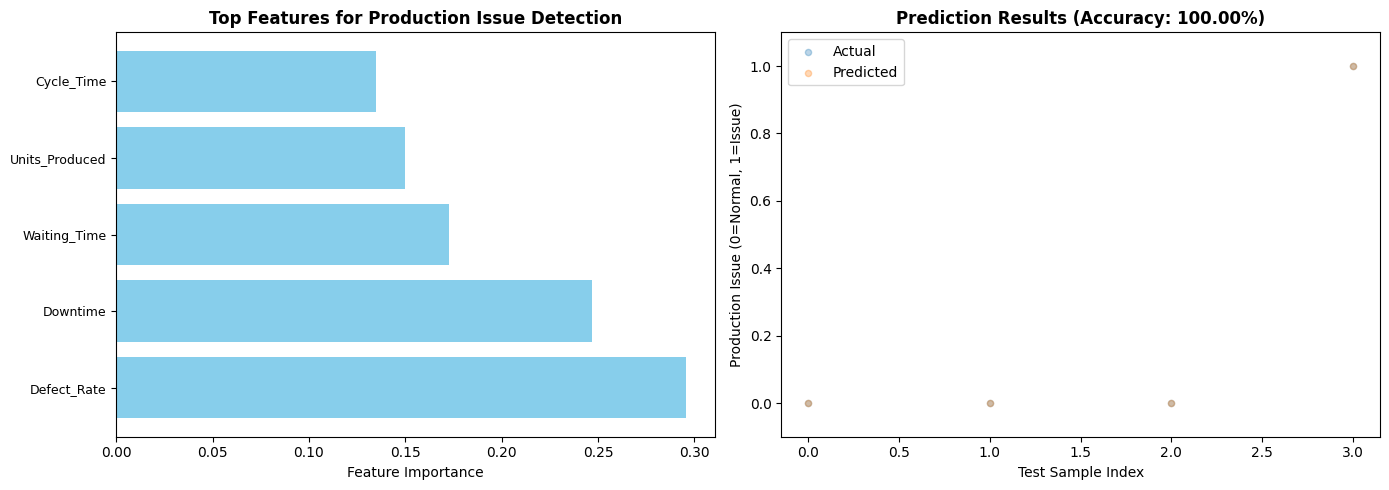

In [41]:
print("=" * 70)
print("Machine Learning - Production Bottleneck Prediction")
print("=" * 70)

X = df[numeric_cols].copy()
X.fillna(X.mean(), inplace=True)

if 'Production_Issue' in df.columns:
    y = df["Production_Issue"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print("\nData Split:")
    print(f"Training set size: {X_train.shape[0]}")
    print(f"Testing set size: {X_test.shape[0]}")
    print(f"Issue distribution in train: {y_train.value_counts().to_dict()}")

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=15
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)

    print("\nModel training complete")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Issue']))

    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop Features for Issue Detection:")
    print(feature_importance.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    n_features = min(len(feature_importance), 10)
    top_features = feature_importance.head(n_features)

    axes[0].barh(range(n_features), top_features['Importance'].values, color='skyblue')
    axes[0].set_yticks(range(n_features))
    axes[0].set_yticklabels(top_features['Feature'].values, fontsize=9)
    axes[0].set_xlabel("Feature Importance")
    axes[0].set_title("Top Features for Production Issue Detection", fontweight='bold')

    axes[1].scatter(range(len(y_test)), y_test.values, alpha=0.3, label='Actual', s=20)
    axes[1].scatter(range(len(y_test)), y_pred, alpha=0.3, label='Predicted', s=20)
    axes[1].set_xlabel("Test Sample Index")
    axes[1].set_ylabel("Production Issue (0=Normal, 1=Issue)")
    axes[1].set_title(f"Prediction Results (Accuracy: {accuracy:.2%})", fontweight='bold')
    axes[1].legend()
    axes[1].set_ylim(-0.1, 1.1)

    plt.tight_layout()
    plt.show()

else:
    print("No Production_Issue column found. Skipping classification model.")

In [42]:
print("=" * 70)
print("Executive Summary - Production Line Analysis")
print("=" * 70)

def generate_recommendation(efficiency_score, missing_ratio, is_issue):
    if is_issue == 1 or efficiency_score > 0.7:
        return "CRITICAL: Immediate intervention required"
    elif efficiency_score > 0.4:
        return "MODERATE: Schedule maintenance review"
    elif missing_ratio > 0.3:
        return "WARNING: Check sensor or data collection"
    else:
        return "EFFICIENT: Continue normal operation"

if 'Production_Issue' in df.columns:
    df["Recommendation"] = df.apply(
        lambda row: generate_recommendation(
            row["Efficiency_Score"],
            row["Missing_Features_Ratio"],
            row["Production_Issue"]
        ), axis=1
    )
else:
    df["Recommendation"] = df.apply(
        lambda row: generate_recommendation(
            row["Efficiency_Score"],
            row["Missing_Features_Ratio"],
            0
        ), axis=1
    )

print("\n" + "=" * 70)
print("Production Line Performance Summary")
print("=" * 70)

print(f"\nTotal Records Analyzed: {len(df):,}")
print(f"Critical Status: {(df['Recommendation'].str.contains('CRITICAL')).sum():,}")
print(f"Moderate Status: {(df['Recommendation'].str.contains('MODERATE')).sum():,}")
print(f"Warning Status: {(df['Recommendation'].str.contains('WARNING')).sum():,}")
print(f"Efficient Status: {(df['Recommendation'].str.contains('EFFICIENT')).sum():,}")

print("\nEfficiency Metrics:")
print(f"Mean Efficiency Score: {df['Efficiency_Score'].mean():.4f}")
print(f"Median Efficiency Score: {df['Efficiency_Score'].median():.4f}")
print(f"Std Dev: {df['Efficiency_Score'].std():.4f}")
print(f"Score Range: [{df['Efficiency_Score'].min():.4f}, {df['Efficiency_Score'].max():.4f}]")

print("\nData Quality Issues:")
print(f"Avg Missing Features: {df['Missing_Features_Ratio'].mean()*100:.1f}%")
print(f"Records with >30% Missing: {(df['Missing_Features_Ratio'] > 0.3).sum():,}")
print(f"Records with >50% Missing: {(df['Missing_Features_Ratio'] > 0.5).sum():,}")

if 'Production_Issue' in df.columns:
    issue_count = (df['Production_Issue'] == 1).sum()
    print("\nProduction Issues:")
    print(f"Total Issues: {issue_count:,} ({issue_count/len(df)*100:.1f}%)")
    print(f"Normal Records: {(df['Production_Issue'] == 0).sum():,}")

print("\nTop 15 Critical Production Records:")
critical_df = df.nlargest(15, "Efficiency_Score")[
    ["Efficiency_Score", "Bottleneck_Score", "Missing_Features_Ratio", "Severity", "Recommendation"]
]
for idx, (i, row) in enumerate(critical_df.iterrows(), 1):
    print(
        f"{idx:2d}. Record {i:4d} | Score: {row['Efficiency_Score']:.4f} | "
        f"Severity: {row['Severity']:10s} | {row['Recommendation']}"
    )

print("\nKey Insights:")
print(f"Production efficiency varies from {df['Efficiency_Score'].min():.4f} to {df['Efficiency_Score'].max():.4f}")
print(f"{(df['Severity'] == 'Critical').sum()} records require immediate attention")
print(f"Missing data impacts {(df['Missing_Features_Ratio'] > 0.2).sum():,} records")
print(f"Clustering identifies {df['Production_Cluster'].nunique()} distinct production patterns")

if 'Production_Issue' in df.columns and 'accuracy' in locals():
    print(f"ML model accuracy: {accuracy:.1%}")

print(f"\nAnalysis complete. All {len(df):,} production records analyzed.")
print("=" * 70)

Executive Summary - Production Line Analysis

Production Line Performance Summary

Total Records Analyzed: 20
Critical Status: 7
Moderate Status: 5
Warning Status: 0
Efficient Status: 8

Efficiency Metrics:
Mean Efficiency Score: 0.5044
Median Efficiency Score: 0.5233
Std Dev: 0.2894
Score Range: [0.0866, 1.0762]

Data Quality Issues:
Avg Missing Features: 0.0%
Records with >30% Missing: 0
Records with >50% Missing: 0

Production Issues:
Total Issues: 5 (25.0%)
Normal Records: 15

Top 15 Critical Production Records:
 1. Record   12 | Score: 1.0762 | Severity: Critical   | CRITICAL: Immediate intervention required
 2. Record    2 | Score: 0.9137 | Severity: Critical   | CRITICAL: Immediate intervention required
 3. Record    8 | Score: 0.8643 | Severity: Critical   | CRITICAL: Immediate intervention required
 4. Record   18 | Score: 0.8039 | Severity: Poor       | CRITICAL: Immediate intervention required
 5. Record   13 | Score: 0.7008 | Severity: Poor       | CRITICAL: Immediate inter